In [61]:
import sys, time, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib


from utils.data_collector import collect_all

from utils.feature_engineering import (
    FEATURE_COLS, TARGET_COL, WEIGHTS,
    basic_checks, run_eda, preprocess,
    compute_score, get_rank, build_dataset,
)
from models.model_training import (
    build_preprocessor, build_pipeline,
    split_data, train_pipeline, train_all_pipelines,
    tune_pipeline_grid, tune_pipeline_random,
    get_best_pipeline, save_pipeline, load_pipeline,
    predict_location,
)
from models.model_evaluation import (
    print_metrics, print_comparison_table, plot_model_comparison,
    plot_actual_vs_predicted, plot_residuals,
    plot_learning_curve, plot_feature_importance,
)
from utils.llm_explainer import explain_location

Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("models").mkdir(parents=True, exist_ok=True)

print("All imports OK")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Weights (sum={sum(WEIGHTS.values())}): {WEIGHTS}")

All imports OK
Features (15): ['ghi', 'dni', 'temperature', 'cloud_pct', 'clearness', 'elevation', 'slope', 'aspect', 'ndvi', 'road_km', 'grid_km', 'wind_speed', 'precipitation', 'humidity', 'land_score']
Weights (sum=1.0): {'ghi': 0.35, 'slope': 0.2, 'land': 0.15, 'ndvi': 0.1, 'cloud': 0.1, 'grid': 0.05, 'road': 0.05}


In [2]:
LOCATIONS = [
    (26.9124, 70.9090, "Jaisalmer"),    (26.2389, 73.0243, "Jodhpur"),
    (27.0238, 74.2179, "Bikaner"),       (25.1462, 74.6399, "Chittorgarh"),
    (26.4499, 74.6399, "Ajmer"),         (24.5854, 73.7125, "Udaipur"),
    (28.0229, 73.3119, "Hanumangarh"),   (27.5530, 76.6346, "Alwar"),
    (23.0225, 72.5714, "Ahmedabad"),     (22.3039, 70.8022, "Rajkot"),
    (23.2156, 72.6369, "Gandhinagar"),   (21.7645, 72.1519, "Bhavnagar"),
    (22.4707, 70.0577, "Jamnagar"),      (23.6693, 72.8258, "Mehsana"),
    (21.5222, 70.4579, "Junagadh"),      (24.1193, 72.3850, "Patan"),
    (15.3647, 75.1240, "Dharwad"),       (14.4644, 76.0078, "Bellary"),
    (16.2076, 77.3463, "Raichur"),       (15.8497, 74.4977, "Bagalkot"),
    (17.3297, 76.8200, "Gulbarga"),      (16.5061, 76.8237, "Bidar"),
    (14.2226, 76.3939, "Chitradurga"),   (13.0827, 79.2904, "Tirupati"),
    (23.1765, 77.4119, "Bhopal"),        (22.7196, 75.8577, "Indore"),
    (25.4358, 78.5941, "Jhansi"),        (26.2183, 78.1828, "Gwalior"),
    (21.2514, 81.6296, "Raipur"),        (24.8892, 74.6214, "Mandsaur"),
    (30.7333, 76.7794, "Chandigarh"),    (31.1471, 75.3412, "Ludhiana"),
    (31.6340, 74.8723, "Amritsar"),      (29.9457, 76.8180, "Karnal"),
    (30.9010, 75.8573, "Jalandhar"),     (14.4426, 79.9865, "Nellore"),
    (13.6288, 79.4192, "Tirupati Rural"),(15.8281, 78.0373, "Kurnool"),
    (14.9091, 78.0099, "Kadapa"),        (16.3067, 80.4365, "Guntur"),
    (17.3850, 78.4867, "Hyderabad"),     (20.0059, 73.7938, "Nashik"),
    (19.9975, 76.6413, "Aurangabad"),    (18.5204, 73.8567, "Pune"),
    (17.6599, 75.9064, "Solapur"),       (20.7002, 77.0082, "Akola"),
    (21.1458, 79.0882, "Nagpur"),        (19.2183, 72.9781, "Mumbai Outskirts"),
    (16.7036, 74.2421, "Kolhapur"),
]
print(f"Defined {len(LOCATIONS)} locations")

Defined 49 locations


In [3]:
DATASET_CSV = Path("data/processed/solar_dataset.csv")

if DATASET_CSV.exists():
    raw_df = pd.read_csv(DATASET_CSV)

else:
    raw_rows = []
    t0 = time.time()

    for i, (lat, lon, name) in enumerate(LOCATIONS, 1):
        try:
            row = collect_all(lat, lon, name)
            raw_rows.append(row)
            print(f"{i}/{len(LOCATIONS)} {name}")
        except:
            pass

    raw_df = build_dataset(raw_rows)

    DATASET_CSV.parent.mkdir(parents=True, exist_ok=True)
    raw_df.to_csv(DATASET_CSV, index=False)

    print("Time:", round(time.time() - t0, 1), "sec")

raw_df.shape

1/49 Jaisalmer
2/49 Jodhpur
3/49 Bikaner
4/49 Chittorgarh
5/49 Ajmer
6/49 Udaipur
7/49 Hanumangarh
8/49 Alwar
9/49 Ahmedabad
10/49 Rajkot
11/49 Gandhinagar
12/49 Bhavnagar
13/49 Jamnagar
14/49 Mehsana
15/49 Junagadh
16/49 Patan
17/49 Dharwad
18/49 Bellary
19/49 Raichur
20/49 Bagalkot
21/49 Gulbarga
22/49 Bidar
23/49 Chitradurga
24/49 Tirupati
25/49 Bhopal
26/49 Indore
27/49 Jhansi
28/49 Gwalior
29/49 Raipur
30/49 Mandsaur
31/49 Chandigarh
32/49 Ludhiana
33/49 Amritsar
34/49 Karnal
35/49 Jalandhar
36/49 Nellore
37/49 Tirupati Rural
38/49 Kurnool
39/49 Kadapa
40/49 Guntur
41/49 Hyderabad
42/49 Nashik
43/49 Aurangabad
44/49 Pune
45/49 Solapur
46/49 Akola
47/49 Nagpur
48/49 Mumbai Outskirts
49/49 Kolhapur
Time: 2656.9 sec


(49, 21)

In [4]:
# Basic checks
basic_checks(raw_df)

,lat,lon,name,ghi,dni,temperature,cloud_pct,clearness,wind_speed,precipitation,...,elevation,slope,aspect,land_use,land_score,ndvi,road_km,grid_km,suitability_score,rank
0,26.9124,70.9090,Jaisalmer,5.7672,5.2548,27.60,23.19,0.64,22.4885,0.6871,...,239.0,1.29,90.00,residential,0.15,0.2,5.000,10.000,67.34,Good
1,26.2389,73.0243,Jodhpur,5.6611,5.3734,26.74,35.33,0.63,17.6959,1.5773,...,220.0,0.73,315.00,unknown,0.50,0.3,4.747,1.730,71.07,Good
2,27.0238,74.2179,Bikaner,5.4720,4.8175,25.94,32.95,0.61,17.1488,1.3011,...,344.0,0.36,135.00,unknown,0.50,0.3,5.000,10.000,72.91,Good
3,25.1462,74.6399,Chittorgarh,5.4806,4.9642,25.38,36.04,0.60,14.3496,2.3868,...,416.0,1.06,345.96,reservoir,0.50,0.3,1.505,10.000,69.62,Good
4,26.4499,74.6399,Ajmer,5.5109,5.0196,25.69,36.14,0.61,16.4559,1.4200,...,477.0,1.39,291.80,unknown,0.50,0.3,1.891,4.219,70.07,Good


,lat,lon,name,ghi,dni,temperature,cloud_pct,clearness,wind_speed,precipitation,...,elevation,slope,aspect,land_use,land_score,ndvi,road_km,grid_km,suitability_score,rank
44,17.6599,75.9064,Solapur,5.4610,4.1066,26.87,45.44,0.57,21.1926,2.0882,...,474.0,1.32,191.31,water,0.00,0.0,1.379,10.000,66.82,Good
45,20.7002,77.0082,Akola,5.2754,4.4107,26.66,42.54,0.56,13.9468,2.5033,...,296.0,1.15,26.57,residential,0.15,0.2,5.000,3.672,63.01,Moderate
46,21.1458,79.0882,Nagpur,5.1732,4.4038,26.91,45.55,0.55,14.4592,3.8115,...,310.0,1.15,333.43,water,0.00,0.0,5.000,6.038,61.39,Moderate
47,19.2183,72.9781,Mumbai Outskirts,5.2942,4.0414,26.77,47.41,0.56,16.9786,4.9123,...,10.0,1.46,45.00,wetland,0.50,0.3,1.912,10.000,66.92,Good
48,16.7036,74.2421,Kolhapur,5.3237,3.9557,24.83,48.76,0.55,18.0781,2.0948,...,570.0,1.39,291.80,water,0.00,0.0,5.000,4.773,61.99,Moderate


,lat,lon,name,ghi,dni,temperature,cloud_pct,clearness,wind_speed,precipitation,...,elevation,slope,aspect,land_use,land_score,ndvi,road_km,grid_km,suitability_score,rank
16,15.3647,75.1240,Dharwad,5.4247,3.9329,24.84,49.17,0.56,19.9121,1.7052,...,626.0,1.63,341.57,railway,0.50,0.3,5.000,10.000,66.67,Good
47,19.2183,72.9781,Mumbai Outskirts,5.2942,4.0414,26.77,47.41,0.56,16.9786,4.9123,...,10.0,1.46,45.00,wetland,0.50,0.3,1.912,10.000,66.92,Good
3,25.1462,74.6399,Chittorgarh,5.4806,4.9642,25.38,36.04,0.60,14.3496,2.3868,...,416.0,1.06,345.96,reservoir,0.50,0.3,1.505,10.000,69.62,Good
34,30.9010,75.8573,Jalandhar,5.0306,4.2391,25.33,40.69,0.58,12.7984,2.0271,...,251.0,0.36,225.00,retail,0.50,0.3,3.586,10.000,69.53,Good
13,23.6693,72.8258,Mehsana,5.5255,4.9342,27.10,34.76,0.60,15.2173,3.1419,...,131.0,0.36,315.00,unknown,0.50,0.3,4.653,4.687,70.23,Good
36,13.6288,79.4192,Tirupati Rural,5.3364,3.4363,26.63,57.15,0.55,14.7381,3.4016,...,154.0,1.15,333.43,unknown,0.50,0.3,0.683,2.542,67.50,Good
24,23.1765,77.4119,Bhopal,5.2231,4.5826,25.74,39.85,0.57,15.2252,2.9370,...,488.0,1.03,0.00,water,0.00,0.0,4.792,10.000,62.00,Moderate
14,21.5222,70.4579,Junagadh,5.3760,4.5305,26.72,41.10,0.58,16.7025,3.0003,...,90.0,1.09,135.00,unknown,0.50,0.3,0.612,10.000,72.09,Good
45,20.7002,77.0082,Akola,5.2754,4.4107,26.66,42.54,0.56,13.9468,2.5033,...,296.0,1.15,26.57,residential,0.15,0.2,5.000,3.672,63.01,Moderate
30,30.7333,76.7794,Chandigarh,5.2246,5.2529,24.16,41.11,0.60,15.7871,2.3526,...,350.0,0.93,213.69,wood,0.50,0.3,5.000,10.000,70.01,Good


(49, 21)

Index(['lat', 'lon', 'name', 'ghi', 'dni', 'temperature', 'cloud_pct',
       'clearness', 'wind_speed', 'precipitation', 'humidity', 'elevation',
       'slope', 'aspect', 'land_use', 'land_score', 'ndvi', 'road_km',
       'grid_km', 'suitability_score', 'rank'],
      dtype='object')

...

None

lat                  0
lon                  0
name                 0
ghi                  0
dni                  0
temperature          0
cloud_pct            0
clearness            0
wind_speed           0
precipitation        0
humidity             0
elevation            0
slope                0
aspect               0
land_use             0
land_score           0
ndvi                 0
road_km              0
grid_km              0
suitability_score    0
rank                 0
dtype: int64

,lat,lon,ghi,dni,temperature,cloud_pct,clearness,wind_speed,precipitation,humidity,elevation,slope,aspect,land_score,ndvi,road_km,grid_km,suitability_score
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,21.664322,75.533453,5.340243,4.335471,26.236939,42.547959,0.574898,16.533039,2.413498,60.502600,322.367347,1.016327,208.225306,0.366327,0.222449,2.855102,7.479469,67.463878
std,5.247705,2.736611,0.205329,0.530940,1.106848,7.847362,0.024759,2.253865,0.845811,6.026302,199.558230,0.583319,110.096957,0.234385,0.132312,1.835859,3.312276,3.310893
min,13.082700,70.057700,4.843000,3.271000,23.860000,23.190000,0.530000,12.461900,0.687100,47.723300,10.000000,0.260000,0.000000,0.000000,0.000000,0.425000,1.494000,60.160000
25%,16.703600,73.712500,5.200100,3.955700,25.380000,36.140000,0.560000,14.794800,1.938600,55.997300,212.000000,0.730000,123.690000,0.150000,0.200000,1.076000,4.216000,65.380000
50%,21.764500,75.857300,5.358700,4.188700,26.500000,41.310000,0.570000,16.455900,2.281400,59.720500,285.000000,0.930000,243.430000,0.500000,0.300000,2.208000,10.000000,67.250000
75%,25.435800,77.346300,5.492900,4.814900,27.020000,48.440000,0.590000,17.685200,2.866600,63.742500,477.000000,1.290000,296.570000,0.500000,0.300000,5.000000,10.000000,69.780000
max,31.634000,81.629600,5.767200,5.373400,28.370000,57.610000,0.640000,22.488500,4.912300,72.693200,776.000000,3.100000,345.960000,0.850000,0.450000,5.000000,10.000000,75.000000


0

rank
Good        40
Moderate     9
Name: count, dtype: int64

In [22]:
# # EDA
# run_eda(raw_df)

import importlib
import utils.feature_engineering as fe

importlib.reload(fe)

<module 'utils.feature_engineering' from 'c:\\AI_Projects\\solar-assignment\\utils\\feature_engineering.py'>

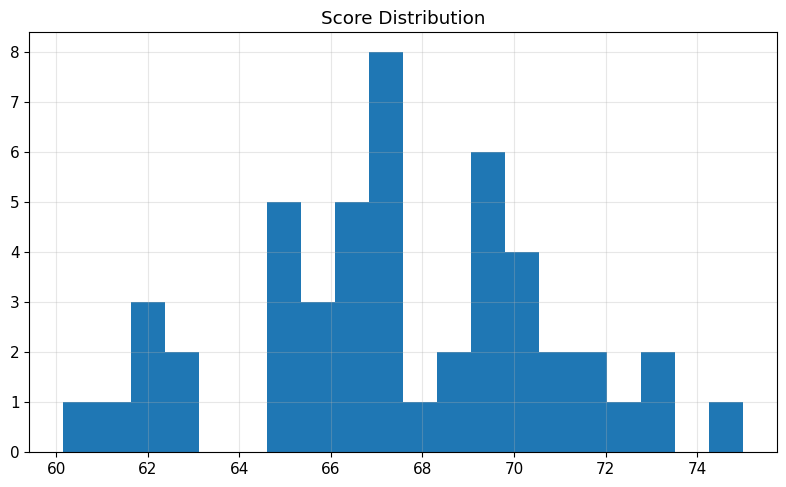

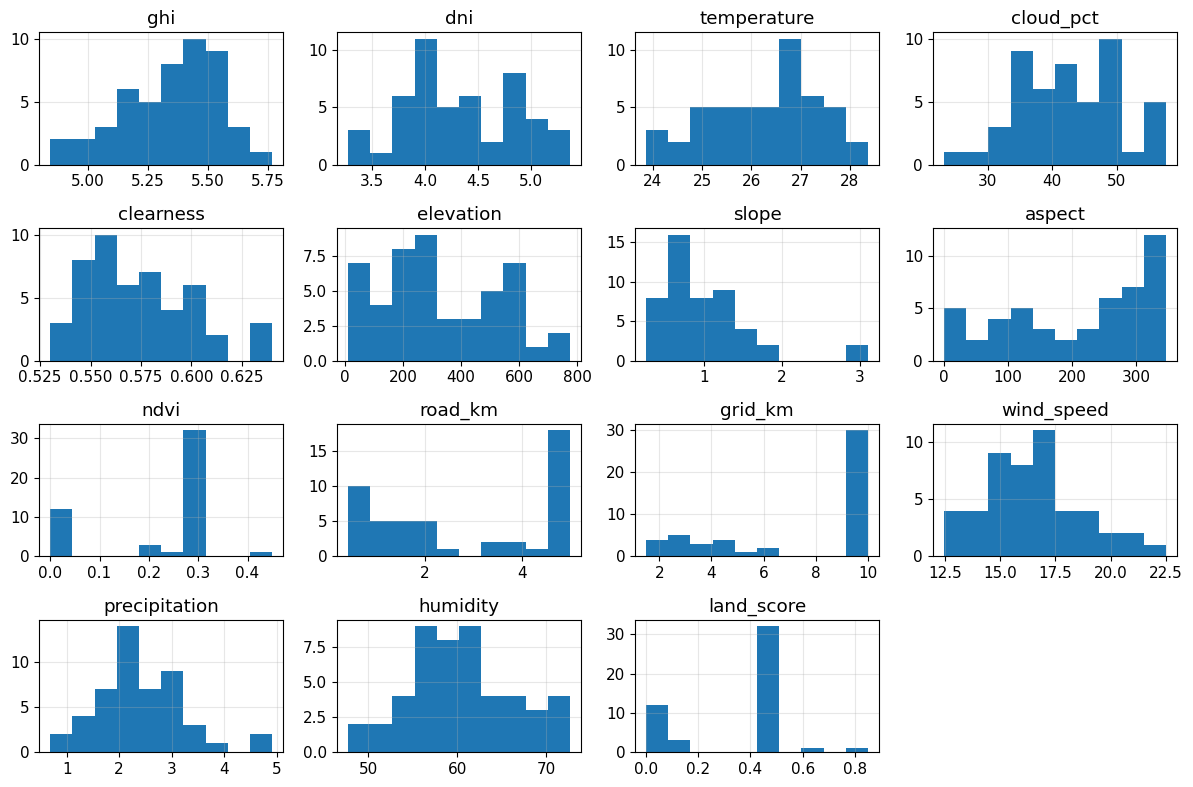

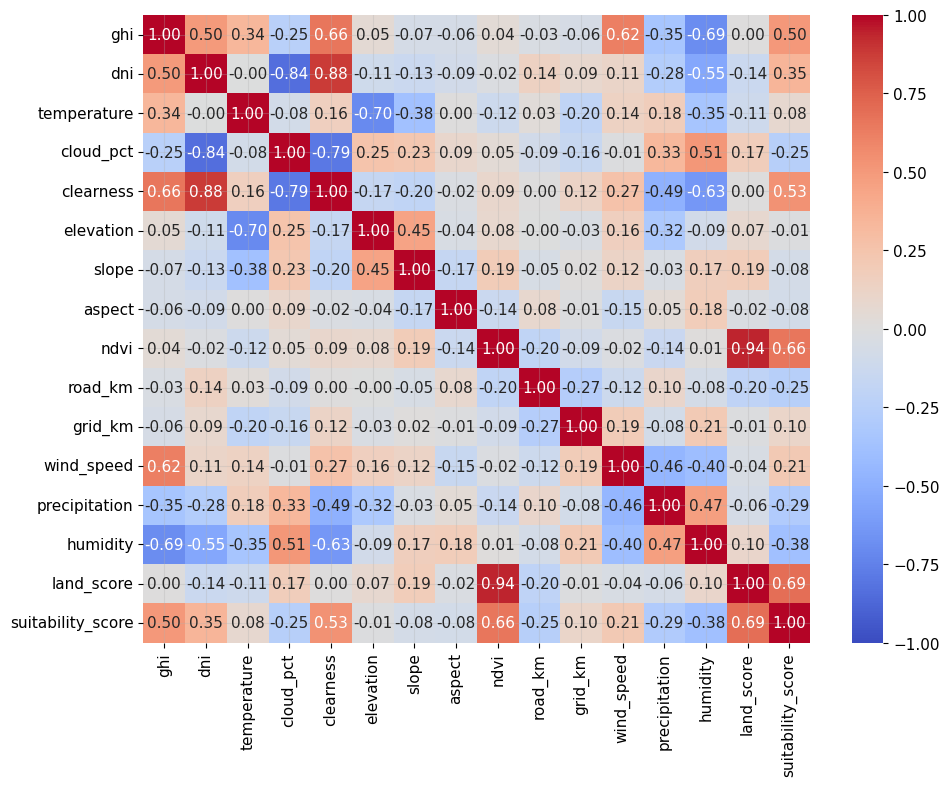

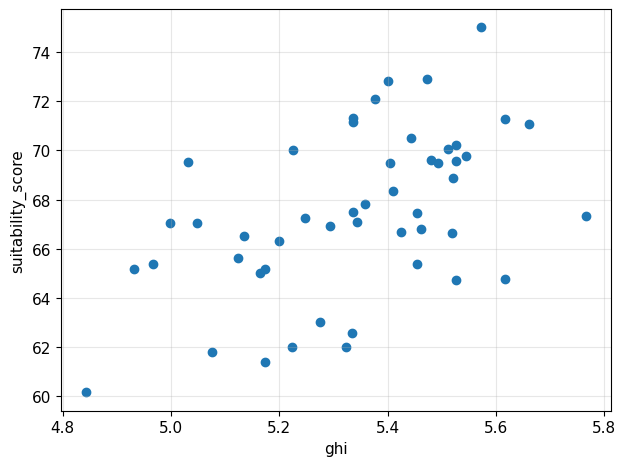

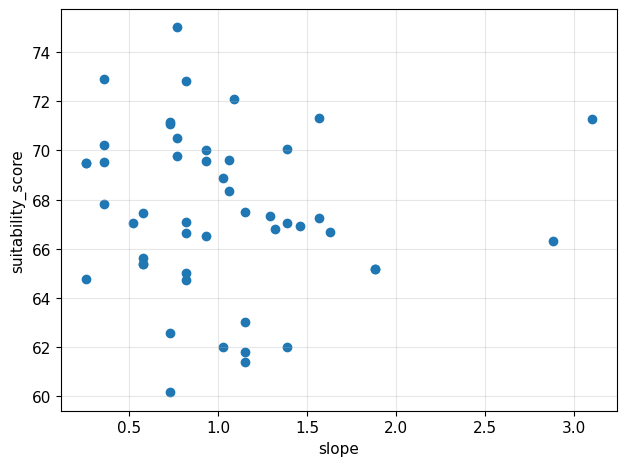

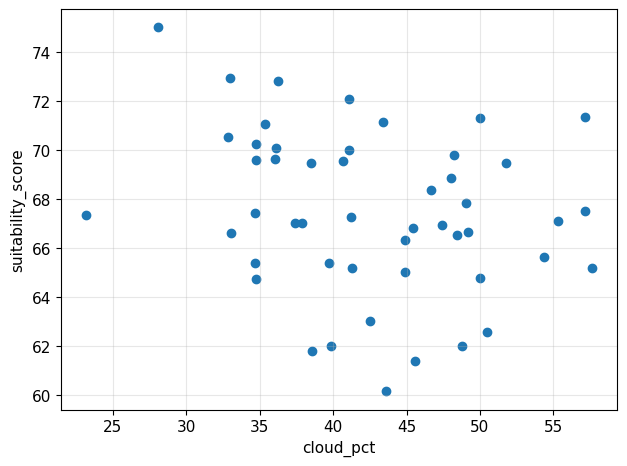

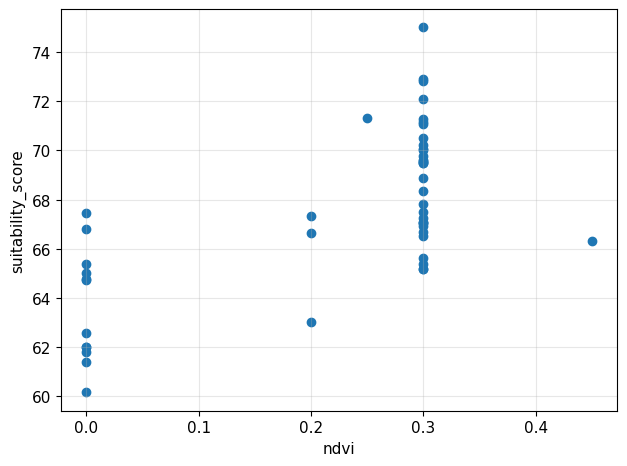

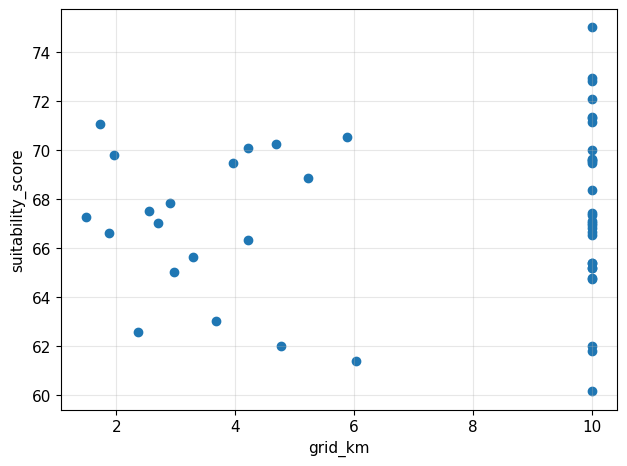

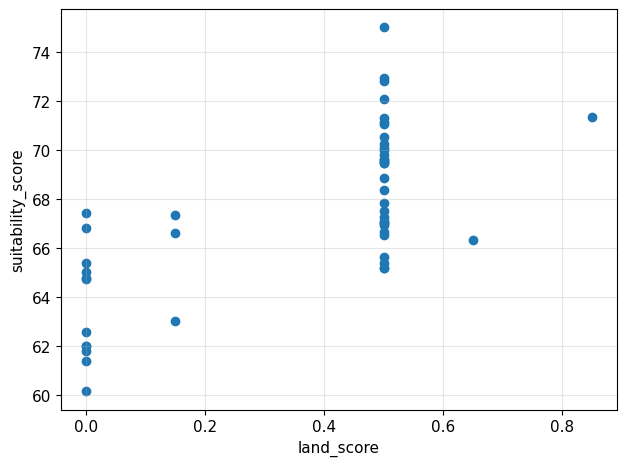

In [23]:
import utils.feature_engineering as fe

fe.run_eda(raw_df)

In [24]:
# Data Preprocessing
processed_df = preprocess(raw_df)
display(processed_df.shape)

(49, 22)

In [28]:
# Feature Engineering
print("Weights:")
for k, v in WEIGHTS.items():
    print(f"{k}: {v}")

print("\nTotal:", sum(WEIGHTS.values()))


print("\nFeature correlation:")
corr = raw_df[FEATURE_COLS].corrwith(raw_df[TARGET_COL]).sort_values(ascending=False)

for k, v in corr.items():
    print(f"{k}: {round(v,3)}")

Weights:
ghi: 0.35
slope: 0.2
land: 0.15
ndvi: 0.1
cloud: 0.1
grid: 0.05
road: 0.05

Total: 1.0

Feature correlation:
land_score: 0.693
ndvi: 0.657
clearness: 0.534
ghi: 0.501
dni: 0.35
wind_speed: 0.214
grid_km: 0.102
temperature: 0.078
elevation: -0.011
slope: -0.076
aspect: -0.085
cloud_pct: -0.25
road_km: -0.251
precipitation: -0.292
humidity: -0.383


In [ ]:
#Model Training
#Split data — no manual scaling needed, Pipeline handles it
X_train, X_test, y_train, y_test = split_data(raw_df)

print("\nPipeline structure preview:")
demo_pipe = build_pipeline(None.__class__)  # just show structure
from sklearn.linear_model import Ridge
demo_pipe = build_pipeline(Ridge())
print(demo_pipe)

39 10

Pipeline structure preview:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ghi', 'dni', 'temperature',
                                                   'cloud_pct', 'clearness',
                                                   'elevation', 'slope',
                                                   'aspect', 'ndvi', 'road_km',
                                                   'grid_km', 'wind_speed',
                                                   'precipitation', 'humidity',
                                                   'land_score']

In [34]:
# Train all 6 baseline pipelines
baseline_results = train_all_pipelines(X_train, X_test, y_train, y_test)

In [35]:
print("INDIVIDUAL PIPELINE METRICS")
for result in baseline_results:
    print_metrics(result)

INDIVIDUAL PIPELINE METRICS
Ridge
R2: 0.6709 MAE: 1.469 RMSE: 1.6248
CV: 0.4641 ± 0.2078
Time: 0.02
Lasso
R2: 0.7132 MAE: 1.3366 RMSE: 1.517
CV: 0.5438 ± 0.1324
Time: 0.01
SVR
R2: 0.3868 MAE: 1.9068 RMSE: 2.218
CV: 0.4776 ± 0.2471
Time: 0.01
RF
R2: 0.5112 MAE: 1.5571 RMSE: 1.9802
CV: 0.3786 ± 0.1997
Time: 0.1
GB
R2: 0.6788 MAE: 1.2065 RMSE: 1.6054
CV: 0.5254 ± 0.1168
Time: 0.06
XGB
R2: 0.0558 MAE: 2.068 RMSE: 2.7524
CV: 0.3997 ± 0.162
Time: 0.06


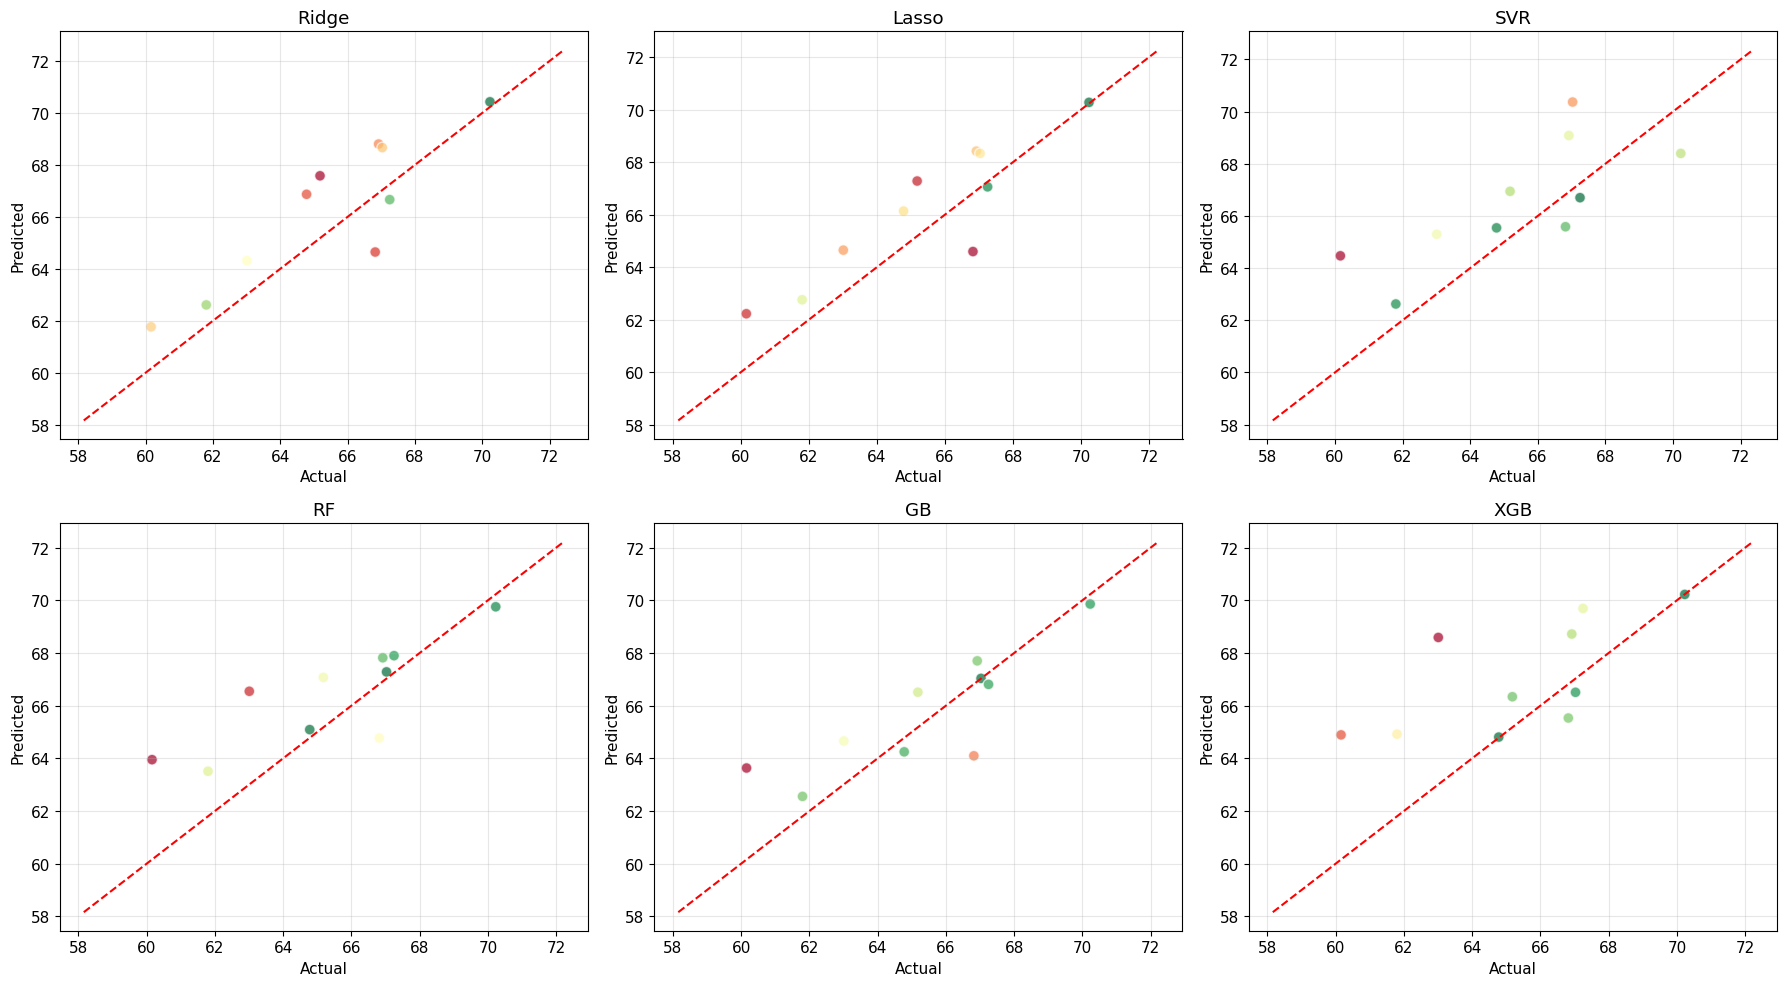

In [36]:
plot_actual_vs_predicted(
    baseline_results, y_test,
    title="Baseline Pipelines — Actual vs Predicted",
    save_as="step7_baseline_actual_vs_pred.png",
)

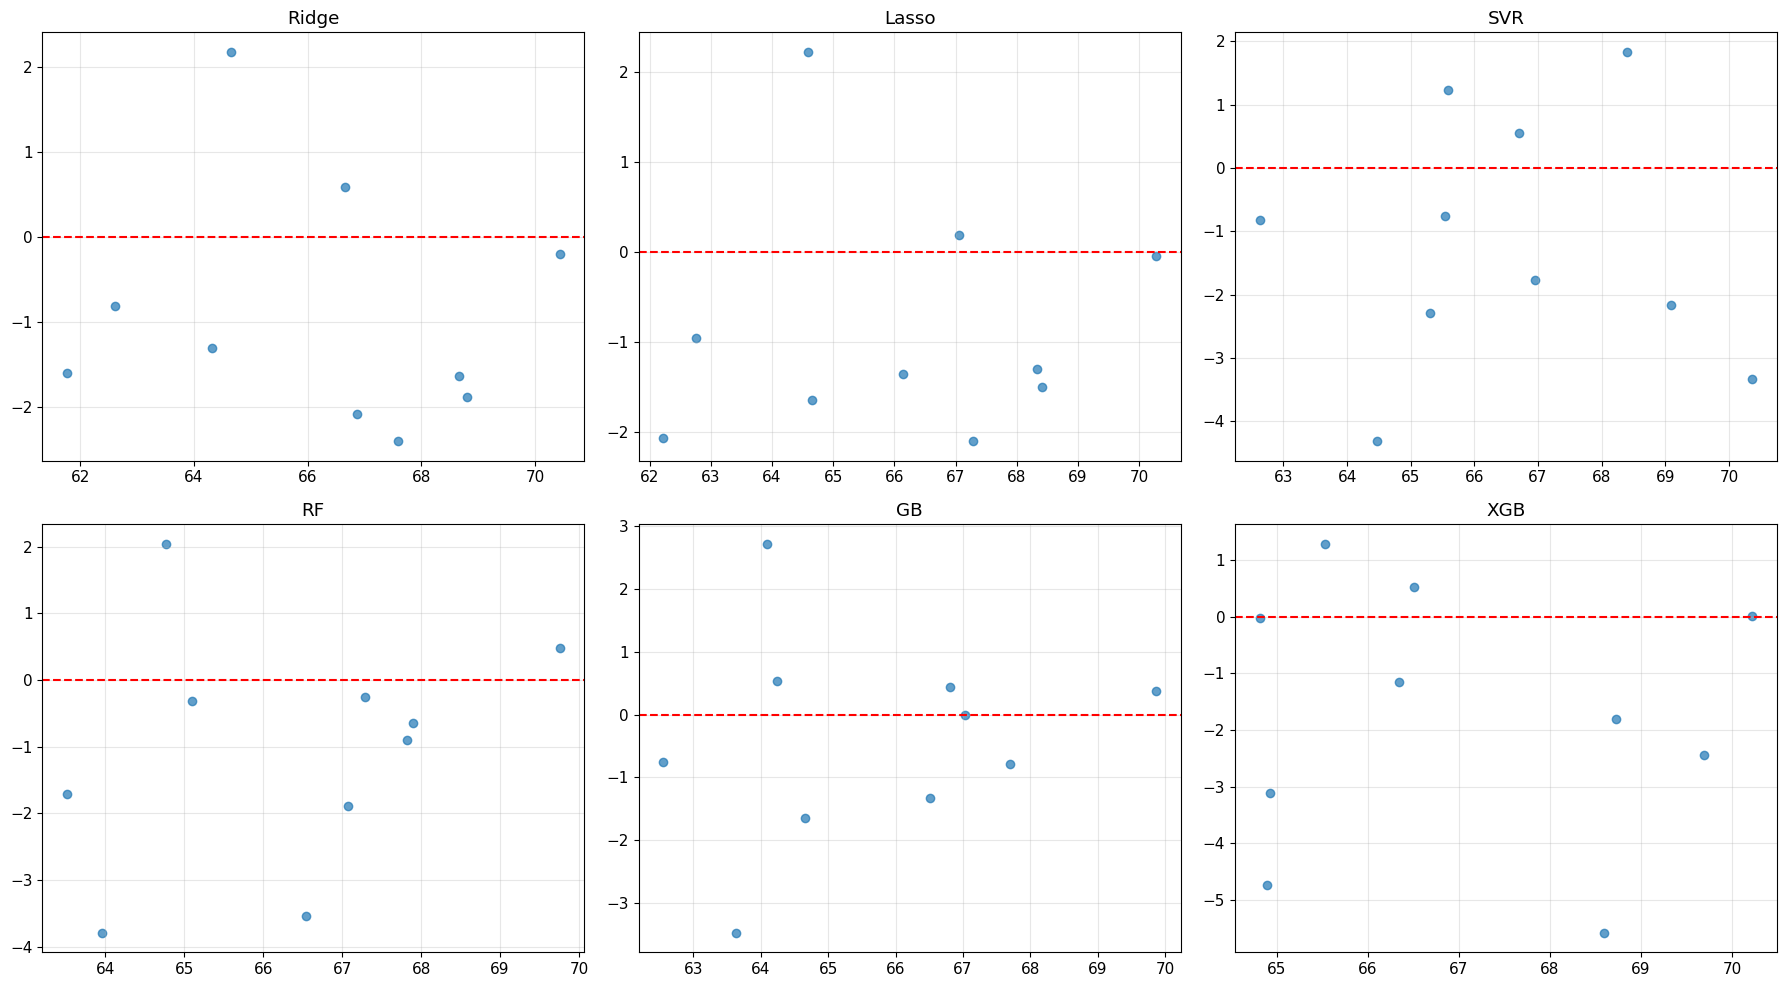

In [37]:
plot_residuals(
    baseline_results, y_test,
    title="Baseline Pipelines — Residuals",
    save_as="step7_baseline_residuals.png",
)

In [39]:
#Model Comparison
baseline_comparison = print_comparison_table(baseline_results, sort_by='R2')

   Model      R2     MAE    RMSE  CV_R2_Mean  CV_R2_Std  Train_Time_sec
1  Lasso  0.7132  1.3366  1.5170      0.5438     0.1324            0.01
4     GB  0.6788  1.2065  1.6054      0.5254     0.1168            0.06
0  Ridge  0.6709  1.4690  1.6248      0.4641     0.2078            0.02
3     RF  0.5112  1.5571  1.9802      0.3786     0.1997            0.10
2    SVR  0.3868  1.9068  2.2180      0.4776     0.2471            0.01
5    XGB  0.0558  2.0680  2.7524      0.3997     0.1620            0.06


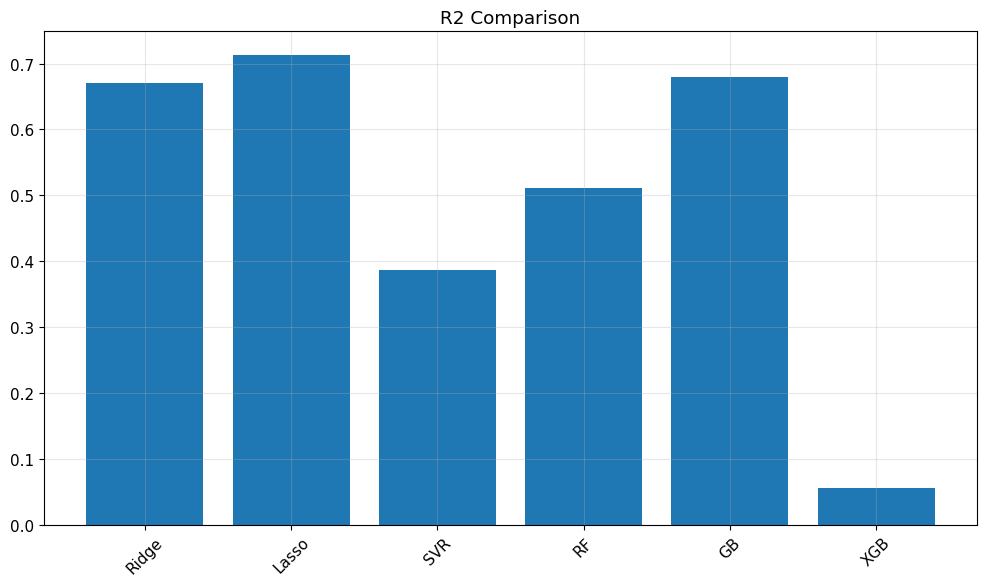

In [40]:
plot_model_comparison(
    baseline_results,
    title="Baseline Pipeline Comparison",
    save_as="step8_baseline_comparison.png",
)

In [41]:
# Feature importance for the best baseline tree model
best_baseline = get_best_pipeline(baseline_results, metric="R2")
plot_feature_importance(
    best_baseline["pipeline_obj"],
    model_name=best_baseline["Model"],
    save_as="step8_baseline_feature_importance.png",
)

In [ ]:
best_baseline["Model"]

'Lasso'

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# ── Random Forest GridSearchCV
rf_param_grid = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [5, 8, None],
    "model__min_samples_split": [2, 5],
    "model__max_features":      ["sqrt", "log2"],
}

rf_tuned = tune_pipeline_grid(
    name       = "Random Forest",
    model      = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid = rf_param_grid,
    X_train    = X_train,
    y_train    = y_train,
    cv         = 5,
    scoring    = "r2",
)
print(f"\nRF best params : {rf_tuned['best_params']}")
print(f"RF best CV R²  : {rf_tuned['best_cv_score']}")


RF best params : {'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_split': 5, 'model__n_estimators': 300}
RF best CV R²  : 0.4381


In [45]:
# ── XGBoost — RandomizedSearchCV
xgb_param_dist = {
    "model__n_estimators":     [200, 300, 500],
    "model__max_depth":        [4, 6, 8],
    "model__learning_rate":    [0.01, 0.05, 0.1],
    "model__subsample":        [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_alpha":        [0, 0.1, 0.5],
}

xgb_tuned = tune_pipeline_random(
    name="XGBoost",
    model=XGBRegressor(random_state=42, tree_method="hist", verbosity=0),
    param_dist=xgb_param_dist,  
    X_train=X_train,
    y_train=y_train,
    n_iter=30,
    cv=5,
    scoring="r2",
)
print(f"\nXGB best params : {xgb_tuned['best_params']}")
print(f"XGB best CV R²  : {xgb_tuned['best_cv_score']}")


XGB best params : {'model__subsample': 0.9, 'model__reg_alpha': 0.1, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}
XGB best CV R²  : 0.7093


In [48]:
# ── Gradient Boosting — RandomizedSearchCV ─────────────────────────────
gb_param_dist = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [3, 5, 7],
    "model__learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "model__subsample":         [0.7, 0.8, 0.9],
    "model__min_samples_split": [2, 5, 10],
}

gb_tuned = tune_pipeline_random(
    name="Gradient Boosting",
    model=GradientBoostingRegressor(random_state=42),
    param_dist= gb_param_dist,
    X_train=X_train,
    y_train=y_train,
    n_iter=30,
    cv=5,
    scoring="r2",
)
print(f"\nGB best params : {gb_tuned['best_params']}")
print(f"GB best CV R²  : {gb_tuned['best_cv_score']}")


GB best params : {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__max_depth': 3, 'model__learning_rate': 0.1}
GB best CV R²  : 0.661


In [ ]:
# Evaluate all tuned pipelines on the test set
print("Evaluating tuned pipelines on test set...")
tuned_results = []

for label, tuned in [
    ("Random Forest (Tuned)",     rf_tuned),
    ("XGBoost (Tuned)",           xgb_tuned),
    ("Gradient Boosting (Tuned)", gb_tuned),
]:
    result = train_pipeline(
        name     = label,
        pipeline = tuned["best_pipeline"],
        X_train  = X_train,
        y_train  = y_train,
        X_test   = X_test,
        y_test   = y_test,
    )
    tuned_results.append(result)

Evaluating tuned pipelines on test set...


In [50]:
# Combine baseline + tuned
all_results = baseline_results + tuned_results

# Final ranked comparison
final_comparison = print_comparison_table(all_results, sort_by="R2")

                       Model      R2     MAE    RMSE  CV_R2_Mean  CV_R2_Std  \
7            XGBoost (Tuned)  0.8148  0.9458  1.2190      0.7093     0.0971   
8  Gradient Boosting (Tuned)  0.7717  1.0822  1.3535      0.6610     0.1424   
1                      Lasso  0.7132  1.3366  1.5170      0.5438     0.1324   
4                         GB  0.6788  1.2065  1.6054      0.5254     0.1168   
0                      Ridge  0.6709  1.4690  1.6248      0.4641     0.2078   
3                         RF  0.5112  1.5571  1.9802      0.3786     0.1997   
6      Random Forest (Tuned)  0.4084  1.7701  2.1786      0.4381     0.1853   
2                        SVR  0.3868  1.9068  2.2180      0.4776     0.2471   
5                        XGB  0.0558  2.0680  2.7524      0.3997     0.1620   

   Train_Time_sec  
7            0.04  
8            0.04  
1            0.01  
4            0.06  
0            0.02  
3            0.10  
6            0.28  
2            0.01  
5            0.06  


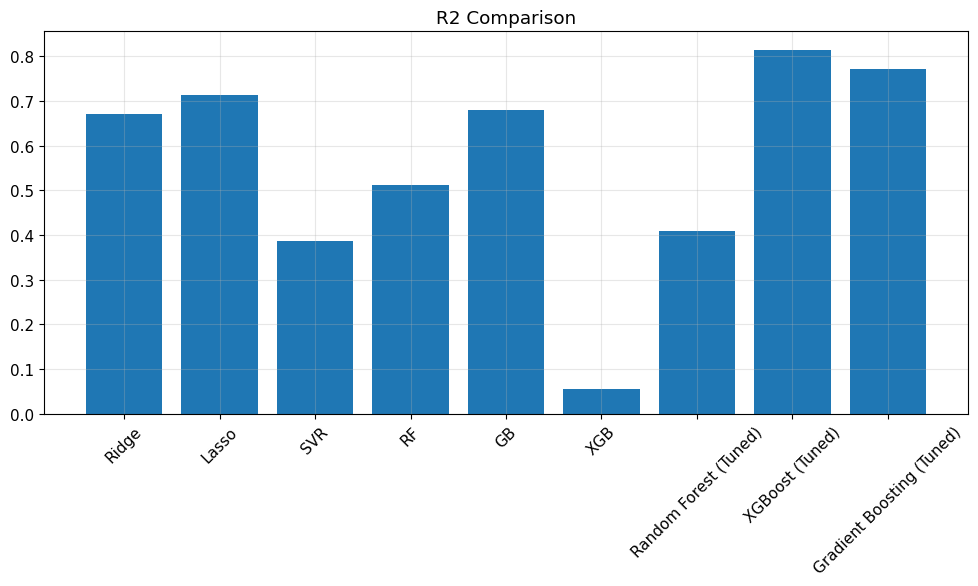

In [51]:
plot_model_comparison(
    all_results,
    title="Final Pipeline Comparison — Baseline + Tuned",
    save_as="step10_final_comparison.png",
)

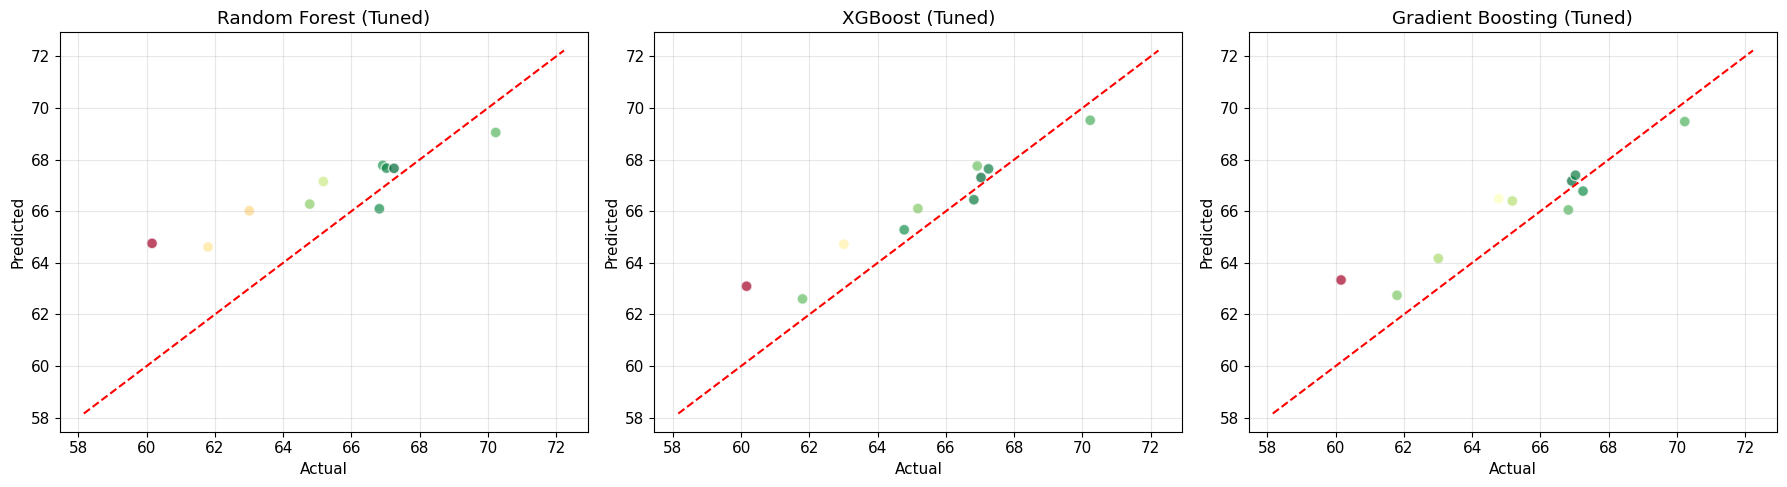

In [52]:
plot_actual_vs_predicted(
    tuned_results, y_test,
    title="Tuned Pipelines — Actual vs Predicted",
    save_as="step10_tuned_actual_vs_pred.png",
)

In [54]:
# Pick the best overall pipeline by R²
best_result   = get_best_pipeline(all_results, metric="R2")
best_pipeline = best_result["pipeline_obj"]

print(f"Best Model: {best_result['Model']}")

Best Model: XGBoost (Tuned)


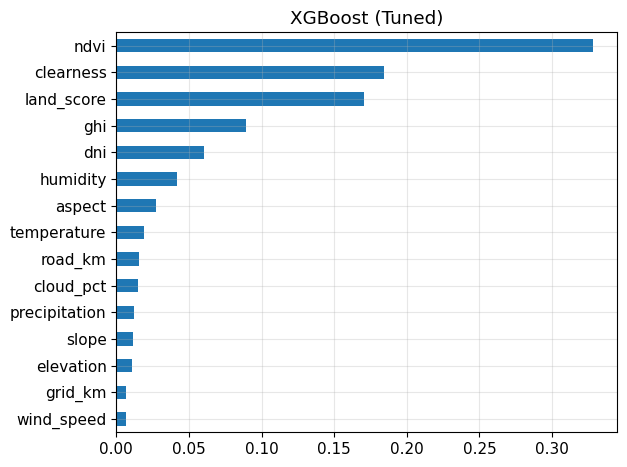

In [55]:
# Feature importance for the best pipeline
plot_feature_importance(
    best_pipeline,
    model_name=best_result["Model"],
    save_as="step10_feature_importance.png",
)

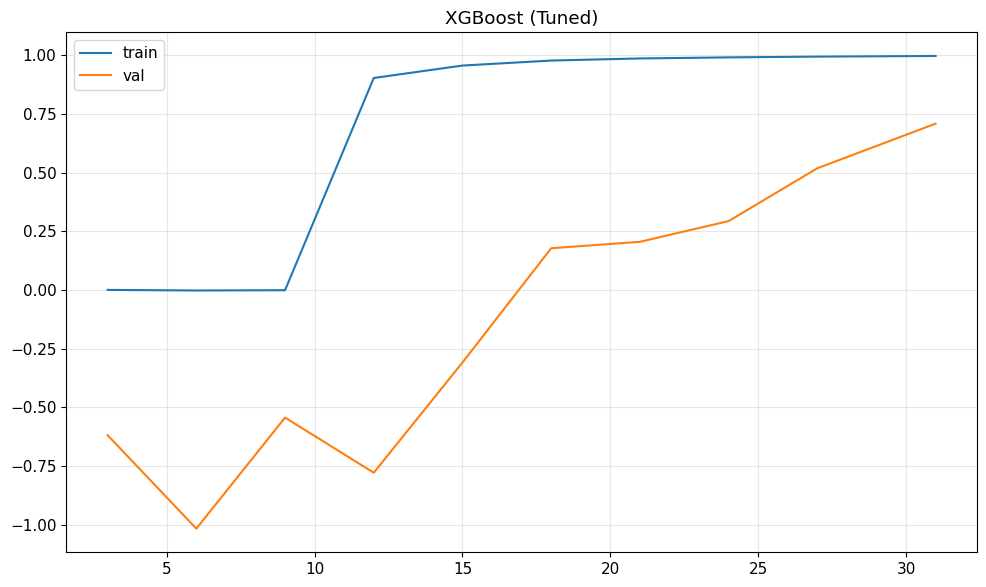

In [56]:
# Learning curve — overfitting/underfitting check
plot_learning_curve(
    best_pipeline,
    X_train,
    y_train,
    model_name=best_result["Model"],
    cv=5,
    save_as="step10_learning_curve.png",
)

In [57]:
# Save — ONE .pkl file contains the full pipeline (preprocessor + model)
save_pipeline(best_pipeline, best_result, save_dir="models")

WindowsPath('models/best_pipeline.pkl')

In [58]:
# Test: reload and predict for a completely new location
print("Testing loaded pipeline on a new location...")

loaded_pipeline, summary = load_pipeline(save_dir="models")

# New location: high-solar site in Rajasthan
new_site = {
    "ghi": 6.8, "dni": 6.2, "temperature": 32.0,
    "cloud_pct": 10.0, "clearness": 0.72,
    "elevation": 250.0, "slope": 2.0, "aspect": 185.0,
    "ndvi": 0.08, "road_km": 3.5, "grid_km": 8.0,
    "wind_speed": 12.0, "precipitation": 1.2,
    "humidity": 25.0, "land_score": 0.95,
}

ml_score   = predict_location(loaded_pipeline, new_site)
rule_score = compute_score(new_site)

print(f"\nNew location test:")
print(f"  ML Pipeline score : {ml_score}  ({get_rank(ml_score)})")
print(f"  Rule-based score  : {rule_score}  ({get_rank(rule_score)})")

Testing loaded pipeline on a new location...

New location test:
  ML Pipeline score : 67.98  (Good)
  Rule-based score  : 92.85  (Excellent)


In [76]:
#LLM (Groq + LLaMA 3)
#The ML model outputs a number. The LLM reads that number + all 15 feature
#values and generates a plain-English investment analysis.
import os
print(os.environ.get("GROQ_API_KEY"))

# get best location
best_row = raw_df.nlargest(1, fe.TARGET_COL).iloc[0]
best_name = best_row.get("name", "Top Site")

# ML prediction (not rule-based)
best_score_ml = predict_location(loaded_pipeline, best_row.to_dict())

# rank
best_rank = fe.get_rank(best_score_ml)

# print info
print(f"Generating LLM explanation for: {best_name}")
print(f"ML Score: {best_score_ml} / 100  ({best_rank})")
print("-" * 55)

# LLM explanation
explanation = explain_location(
    score=best_score_ml,
    rank=best_rank,
    features=best_row.to_dict(),
    location_name=best_name,
)

print(explanation)

None
Generating LLM explanation for: Hanumangarh
ML Score: 74.42 / 100  (Good)
-------------------------------------------------------
No API key found

Hanumangarh scored 74.42/100 (Good)

Good:
- GHI: 5.5721
- Slope: 0.77
- Land: 0.5

Concerns:
- Cloud: 28.08
- Grid: 10.0
- Road: 0.587

Recommendation:
Good site



In [71]:
# Explain a Moderate site for contrast
mid_rows = raw_df[(raw_df[TARGET_COL] >= 50) & (raw_df[TARGET_COL] < 65)]
if len(mid_rows) > 0:
    mid_row   = mid_rows.iloc[0]
    mid_name  = mid_row.get("name", "Moderate Site")
    mid_score = predict_location(loaded_pipeline, mid_row.to_dict())
    mid_rank  = get_rank(mid_score)

    print(f"\nContrast — MODERATE site: {mid_name}")
    print(f"ML Score: {mid_score} / 100  ({mid_rank})")
    print("-" * 55)

    print(explain_location(
        score=mid_score, rank=mid_rank,
        features=mid_row.to_dict(), location_name=mid_name,
    ))


Contrast — MODERATE site: Gandhinagar
ML Score: 64.71 / 100  (Moderate)
-------------------------------------------------------
No API key found

Gandhinagar scored 64.71/100 (Moderate)

Good:
- GHI: 5.5255
- Slope: 0.82
- Land: 0.0

Concerns:
- Cloud: 34.76
- Grid: 10.0
- Road: 4.178

Recommendation:
Needs review



In [75]:
print("=" * 60)
print("PIPELINE PROJECT")
print("=" * 60)
print(f"Dataset        : {len(raw_df)} locations, {len(FEATURE_COLS)} features")
print(f"Models trained : {len(all_results)}  (6 baseline + 3 tuned)")
print(f"Best pipeline  : {best_result['Model']}")
print(f"  R²    = {best_result['R2']}")
print(f"  MAE   = {best_result['MAE']}")
print(f"  RMSE  = {best_result['RMSE']}")
print(f"  CV R² = {best_result['CV_R2_Mean']} ± {best_result['CV_R2_Std']}")


PIPELINE PROJECT
Dataset        : 49 locations, 15 features
Models trained : 9  (6 baseline + 3 tuned)
Best pipeline  : XGBoost (Tuned)
  R²    = 0.8148
  MAE   = 0.9458
  RMSE  = 1.219
  CV R² = 0.7093 ± 0.0971


In [77]:
import os
print(os.environ.get("GROQ_API_KEY"))

None
